# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

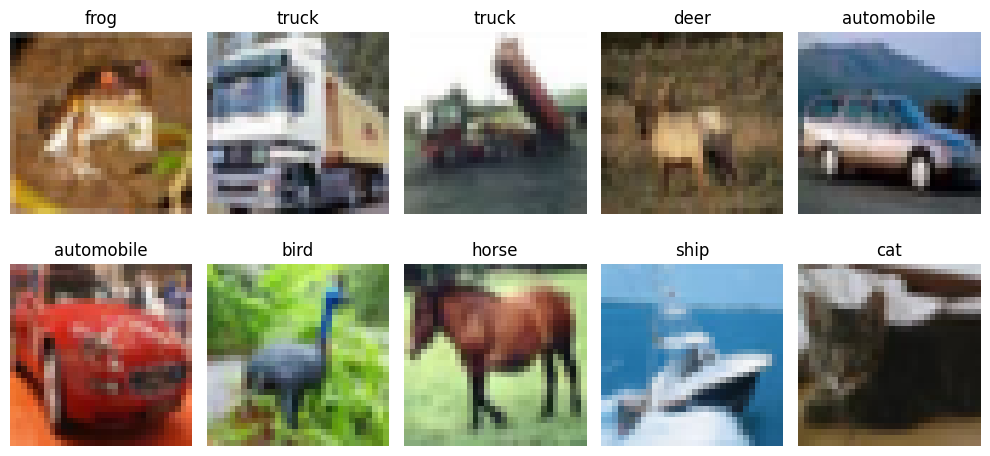

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2641 - loss: 2.0056 - val_accuracy: 0.3362 - val_loss: 1.8475
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3050 - loss: 1.8880 - val_accuracy: 0.3478 - val_loss: 1.8076
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3366 - loss: 1.8231 - val_accuracy: 0.3814 - val_loss: 1.7502
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3478 - loss: 1.7894 - val_accuracy: 0.3590 - val_loss: 1.7730
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3586 - loss: 1.7586 - val_accuracy: 0.3950 - val_loss: 1.7129
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3695 - loss: 1.7309 - val_accuracy: 0.3980 - val_loss: 1.7032
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3744 - loss: 1.7160 - val_accuracy: 0.3970 - val_loss: 1.6798
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3776 - loss: 1.7104 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4322 - loss: 1.6235
ANN Test Accuracy: 0.43220001459121704



# Increase ANN layers and observe performance

In [13]:
from tensorflow.keras import models, layers

ann_model = models.Sequential([

    # Input Layer
    layers.Input(shape=(3072,)),

    # Hidden Layer 1
    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden Layer 2
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden Layer 3
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    # Hidden Layer 4
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.3185 - loss: 1.8906 - val_accuracy: 0.2620 - val_loss: 2.1371
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3826 - loss: 1.7198 - val_accuracy: 0.3432 - val_loss: 1.8085
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4035 - loss: 1.6632 - val_accuracy: 0.3968 - val_loss: 1.6927
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4103 - loss: 1.6464 - val_accuracy: 0.3932 - val_loss: 1.6808
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4169 - loss: 1.6272 - val_accuracy: 0.3920 - val_loss: 1.7193
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4275 - loss: 1.6043 - val_accuracy: 0.4392 - val_loss: 1.5674
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4339 - loss: 1.5855 - val_accuracy: 0.4664 - val_loss: 1.5104
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4392 - loss: 1.5694 - val_accuracy: 

In [14]:
print("Training Accuracy:",
      ann_history.history['accuracy'][-1])

print("Validation Accuracy:",
      ann_history.history['val_accuracy'][-1])

Training Accuracy: 0.4750666618347168
Validation Accuracy: 0.4918000102043152


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4760 - loss: 1.4830 - val_accuracy: 0.5432 - val_loss: 1.2836
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6162 - loss: 1.1005 - val_accuracy: 0.5170 - val_loss: 1.3535
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6771 - loss: 0.9326 - val_accuracy: 0.5954 - val_loss: 1.2021
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7189 - loss: 0.8128 - val_accuracy: 0.6342 - val_loss: 1.1860
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7473 - loss: 0.7239 - val_accuracy: 0.7208 - val_loss: 0.8244
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7790 - loss: 0.6390 - val_accuracy: 0.7222 - val_loss: 0.8276
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7979 - loss: 0.5745 - val_accuracy: 0.7350 - val_loss: 0.8278
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8172 - loss: 0.5168 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7187 - loss: 0.8902
CNN Test Accuracy: 0.7186999917030334


Change CNN filters from 32→64→128

Increase epochs to 20

Add EarlyStopping

Add data augmentation training

In [16]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train_norm)

# CNN Model
cnn_model = models.Sequential([

    layers.Input(shape=(32,32,3)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

# Compile
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Training
cnn_history = cnn_model.fit(
    datagen.flow(
        x_train_norm,
        y_train,
        batch_size=64
    ),
    epochs=20,
    validation_data=(x_test_norm, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.4430 - loss: 1.5642 - val_accuracy: 0.4986 - val_loss: 1.3575
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.5632 - loss: 1.2421 - val_accuracy: 0.6243 - val_loss: 1.0702
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.6164 - loss: 1.1004 - val_accuracy: 0.6032 - val_loss: 1.1708
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.6492 - loss: 1.0100 - val_accuracy: 0.6164 - val_loss: 1.2044
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.6717 - loss: 0.9554 - val_accuracy: 0.6521 - val_loss: 1.0446
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.6888 - loss: 0.9046 - val_accuracy: 0.6454 - val_loss: 1.1453
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.7069 - loss: 0.8620 - val_accuracy: 0.7167 - val_loss: 0.8574
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7151 - loss: 0.8356 - 

## 📈 Compare Learning Curves

In [17]:
test_loss, test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print(f"Test Accuracy: {test_acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7498 - loss: 0.7206
Test Accuracy: 74.98%


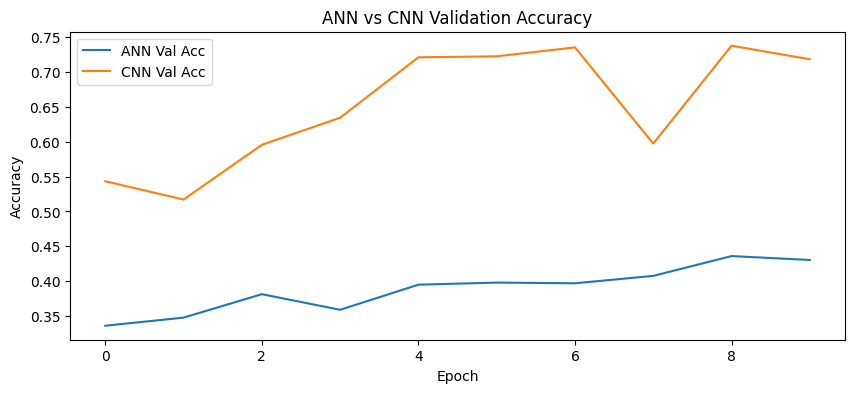

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

new graph after update ann and cnn model

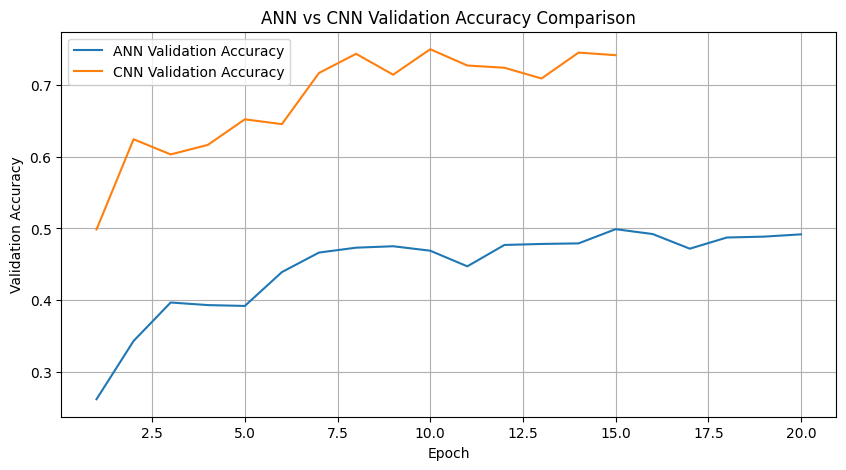

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# ANN Validation Accuracy
plt.plot(
    range(1, len(ann_history.history['val_accuracy']) + 1),
    ann_history.history['val_accuracy'],
    label='ANN Validation Accuracy'
)

# CNN Validation Accuracy
plt.plot(
    range(1, len(cnn_history.history['val_accuracy']) + 1),
    cnn_history.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy Comparison")

plt.legend()
plt.grid(True)

plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.3708 - loss: 1.7240 - val_accuracy: 0.5058 - val_loss: 1.3760
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4721 - loss: 1.4715 - val_accuracy: 0.5476 - val_loss: 1.2881
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5077 - loss: 1.3761 - val_accuracy: 0.5804 - val_loss: 1.1635
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5290 - loss: 1.3233 - val_accuracy: 0.5978 - val_loss: 1.1258
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5449 - loss: 1.2867 - val_accuracy: 0.6050 - val_loss: 1.1317
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5580 - loss: 1.2541 - val_accuracy: 0.6042 - val_loss: 1.1002
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5655 - loss: 1.2326 - val_accuracy: 0.5960 - val_loss: 1.1199
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5726 - loss: 1.2

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4322
1,CNN,0.7187


new comparision

In [19]:
# Evaluate ANN
ann_test_loss, ann_test_acc = ann_model.evaluate(
    x_test_flat,
    y_test
)

# Evaluate CNN
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

# Comparison Table
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy (%)": [
        ann_test_acc * 100,
        cnn_test_acc * 100
    ]
})

comparison

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4936 - loss: 1.4514
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7498 - loss: 0.7206


,Model,Test Accuracy (%)
0,ANN,49.360001
1,CNN,74.980003


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

ANN (Artificial Neural Network) can classify images, but it treats images as flattened data and does not preserve spatial relationships between pixels. This limits performance on image-based tasks.
CNN (Convolutional Neural Network) performs better because it automatically extracts spatial and hierarchical features such as edges, shapes, textures, and patterns directly from images.
Increasing model depth and applying techniques like Dropout, Batch Normalization, Data Augmentation, and Early Stopping improved generalization and reduced overfitting.
The comparison shows that CNN achieves higher validation and test accuracy than ANN for image classification tasks.
This project strengthens understanding of deep learning concepts, model optimization, and computer vision workflows, providing a strong foundation for computer vision interviews, real-world image classification projects, and advanced deep learning applications.